### **Description**

This recipe shows how to calculate the barotropic stream function for the North Atlantic Ocean using annual-mean outputs from the National Oceanography Centre Near-Present-Day global eORCA1 configuration of NEMO forced using JRA55-do from 1976-2024.

For more details on this model configuration and the available outputs, users can explore the Near-Present-Day documentation [here](https://noc-msm.github.io/NOC_Near_Present_Day/).

---
### **Background**
The barotropic stream function is routinely used to characterise the large-scale ocean circulation $\psi_{xy}$ and can be defined using the meridional velocity field at time $t$ as follows:

$$\Psi_{xy}(\lambda, \phi, t) = \int_{x_w}^{x} \int_{-H}^{\eta} v(\lambda, \phi, z, t) \ dz \ dx$$

where the meridional velocity $v(\lambda, \phi, z, t)$ is first integrated from the sea surface $\eta$ to the seafloor $-H$ before being accumulated zonally from the western ($x_w$) to the eastern ($x_e$) boundary of our model domain.

---

In [1]:
# -- Import required packages -- #
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import xarray as xr

from nemo_cookbook import NEMODataTree

xr.set_options(display_style="text")

### **Using Dask**

**Optional: Connect Client to Dask Local Cluster to run analysis in parallel.**

Note that, although using Dask is not strictly necessary for this simple example using eORCA1, if we wanted to generalise this recipe to eORCA025 or eORCA12 outputs, using Dask would be essential to avoid unnecessary slow calculations using only a single process.

In [ ]:
# -- Initialise Dask Local Cluster -- #
import os

import dask
from dask.distributed import Client, LocalCluster

# Update temporary directory for Dask workers:
dask.config.set({'temporary_directory': f"{os.getcwd()}/dask_tmp",
                 'local_directory': f"{os.getcwd()}/dask_tmp"
                 })

# Create Local Cluster:
cluster = LocalCluster(n_workers=4, threads_per_worker=3, memory_limit='5GB')
client = Client(cluster)
client

### **Accessing NEMO Model Data**
**Let's begin by loading the grid variables for our eORCA1 JRA-55 model from the [JASMIN Object Store](https://help.jasmin.ac.uk/docs/short-term-project-storage/using-the-jasmin-object-store/)**. 

**Alternatively, you can replace the ``domain_filepath`` below with a file path to your domain_cfg.nc file and read this with xarray's ``open_dataset()`` function.**

In [9]:
# Define directory path to ancillary files:
domain_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/domain_cfg"

# Open eORCA1 NEMO model domain_cfg:
ds_domain = xr.open_zarr(domain_url, consolidated=True, chunks={})

ds_domain

<xarray.Dataset> Size: 709MB
Dimensions:       (y: 331, x: 360, nav_lev: 75)
Coordinates:
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
  * x             (x) int64 3kB 0 1 2 3 4 5 6 7 ... 353 354 355 356 357 358 359
  * y             (y) int64 3kB 0 1 2 3 4 5 6 7 ... 324 325 326 327 328 329 330
Data variables: (12/49)
    atlmsk        (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bathy_metry   (y, x) float32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    bottom_level  (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1f           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1t           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    e1u           (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    ...            ...
    top_level     (y, x) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    umaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    vmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
    vmaskutil     (y, x) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    wmask         (nav_lev, y, x) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
Attributes:
    CfgName:    UNKNOWN
    CfgIndex:   -999
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     F
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  01/03/2025 22:19:49 -0000

**Next, we need to import the meridional velocity and vertical grid cell thicknesses stored at V-points in a single dataset.**


In [3]:
# Define directory path to model output files:
gridV_url = "https://noc-msm-o.s3-ext.jc.rl.ac.uk/npd-eorca1-jra55v1/V1y"

# Construct NEMO model V-grid dataset, including vertical grid cell thicknesses (m) and meridional velocities (m/s):
ds_gridV = xr.open_zarr(gridV_url, consolidated=True, chunks={})

ds_gridV

<xarray.Dataset> Size: 9GB
Dimensions:               (depthv: 75, axis_nbounds: 2, time_counter: 49,
                           y: 331, x: 360)
Coordinates:
  * depthv                (depthv) float32 300B 0.5058 1.556 ... 5.902e+03
    nav_lat               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    nav_lon               (y, x) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    time_centered         (time_counter) datetime64[ns] 392B dask.array<chunksize=(1,), meta=np.ndarray>
  * time_counter          (time_counter) datetime64[ns] 392B 1976-07-02 ... 2...
Dimensions without coordinates: axis_nbounds, y, x
Data variables: (12/13)
    depthv_bounds         (depthv, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
    e3v                   (time_counter, depthv, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    hfy                   (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_adv               (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    hfy_diff              (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    somesatr              (time_counter, y, x) float32 23MB dask.array<chunksize=(1, 331, 360), meta=np.ndarray>
    ...                    ...
    time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 784B dask.array<chunksize=(1, 2), meta=np.ndarray>
    time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 784B dask.array<chunksize=(1, 2), meta=np.ndarray>
    v2o                   (time_counter, depthv, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vmo                   (time_counter, depthv, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo                    (time_counter, depthv, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
    vo_eiv                (time_counter, depthv, y, x) float32 2GB dask.array<chunksize=(1, 25, 331, 360), meta=np.ndarray>
Attributes:
    name:         OUTPUT/eORCA1_1y_grid_V
    description:  ocean V grid variables
    title:        ocean V grid variables
    Conventions:  CF-1.6
    timeStamp:    2024-Dec-09 10:18:04 GMT
    uuid:         b77cb501-a564-4451-8908-d66fe201e54a

### **Creating a NEMODataTree**

**Next, let's create a NEMODataTree to store our domain and V-grid variables for the eORCA1 model.**

**Since all land-sea masks expected by `NEMODataTree` are included in `ds_domain`, let's specify `read_mask = True` to read rather than calculate land-sea masks when constructing our `NEMODataTree`.**

In [4]:
# Define dictionary of grid datasets defining eORCA1 parent model domain with no child/grand-child nests:
datasets = {"parent": {"domain": ds_domain, "gridV": ds_gridV}}

# Initialise a new NEMODataTree whose parent domain is zonally periodic & north-folding on F-points:
nemo = NEMODataTree.from_datasets(datasets=datasets, iperio=True, nftype="F", read_mask=True)

nemo

<xarray.DataTree 'NEMO model'>
Group: /
│   Dimensions:               (time_counter: 49, axis_nbounds: 2)
│   Coordinates:
│       time_centered         (time_counter) datetime64[ns] 392B dask.array<chunksize=(1,), meta=np.ndarray>
│     * time_counter          (time_counter) datetime64[ns] 392B 1976-07-02 ... 2...
│   Dimensions without coordinates: axis_nbounds
│   Data variables:
│       time_centered_bounds  (time_counter, axis_nbounds) datetime64[ns] 784B dask.array<chunksize=(1, 2), meta=np.ndarray>
│       time_counter_bounds   (time_counter, axis_nbounds) datetime64[ns] 784B dask.array<chunksize=(1, 2), meta=np.ndarray>
│   Attributes:
│       nftype:   F
│       iperio:   True
├── Group: /gridT
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphit         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamt         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360
│       Data variables:
│           e1t           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2t           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           top_level     (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           bottom_level  (j, i) int32 477kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           tmask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           tmaskutil     (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridU
│       Dimensions:       (j: 331, i: 360, k: 75)
│       Coordinates:
│           gphiu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamu         (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k             (k) int64 600B 1 2 3 4 5 6 7 8 9 ... 68 69 70 71 72 73 74 75
│         * j             (j) int64 3kB 1 2 3 4 5 6 7 8 ... 325 326 327 328 329 330 331
│         * i             (i) float64 3kB 1.5 2.5 3.5 4.5 ... 357.5 358.5 359.5 360.5
│       Data variables:
│           e1u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           e2u           (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           umask         (k, j, i) int8 9MB dask.array<chunksize=(75, 331, 360), meta=np.ndarray>
│           umaskutil     (j, i) int8 119kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│       Attributes:
│           nftype:   F
│           iperio:   True
├── Group: /gridV
│       Dimensions:               (k: 75, axis_nbounds: 2, time_counter: 49, j: 331,
│                                  i: 360)
│       Coordinates:
│         * depthv                (k) float32 300B 0.5058 1.556 ... 5.698e+03 5.902e+03
│           time_centered         (time_counter) datetime64[ns] 392B dask.array<chunksize=(1,), meta=np.ndarray>
│           gphiv                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│           glamv                 (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
│         * k                     (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
│         * j                     (j) float64 3kB 1.5 2.5 3.5 4.5 ... 329.5 330.5 331.5
│         * i                     (i) int64 3kB 1 2 3 4 5 6 ... 355 356 357 358 359 360
│       Dimensions without coordinates: axis_nbounds
│       Data variables: (12/17)
│           depthv_bounds         (k, axis_nbounds) float32 600B dask.array<chunksize=(25, 2), meta=np.ndarray>
│           e3v       

### **Calculating the Barotropic Stream Function**
**Now we have constructed our `NEMODataTree`, let's calculate the time-mean barotropic stream function.**

$$\psi_{xy}(t) = \sum_{i^{*}=1}^{i} \sum_{k} (e_{1v} . e_{3v}(t) . v(t))$$

In this example, our eORCA1 model uses $z^{*}$ vertical coordinates, so we will use the `integral()` method to perform integration along the $i$ and $k$ dimensions of the NEMO model grid.

The resulting 2-dimensional barotropic stream function represents the depth-integrated volume transport in the Atlantic Ocean.

In [5]:
# Define Atlantic Ocean basin mask:
atlmask = ds_domain['atlmsk'].rename({"x":"i", "y":"j"}).astype(bool)
# Assign (i,j) coordinates of V-points:
atlmask['i'] = atlmask['i'] + 1
atlmask['j'] = atlmask['j'] + 1.5

# Compute barotropic stream function:
bsf_atl = nemo["gridV/vo"].integral(dims=["i", "k"], cum_dims=["i"], dir="+1", mask=atlmask)

bsf_atl

<NEMODataTree 'NEMO model'>
  <NEMODataArray 'integral_ik(vo)' (Domain: '.', Grid: 'gridV', Grid Type: 'V')>

<xarray.DataArray 'integral_ik(vo)' (time_counter: 49, j: 331, i: 360)> Size: 47MB
dask.array<nancumsum, shape=(49, 331, 360), dtype=float64, chunksize=(1, 331, 360), chunktype=numpy.ndarray>
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 392B 1976-07-02 ... 2024-07-02
    time_centered  (time_counter) datetime64[ns] 392B dask.array<chunksize=(1,), meta=np.ndarray>
    gphiv          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
    glamv          (j, i) float64 953kB dask.array<chunksize=(331, 360), meta=np.ndarray>
  * j              (j) float64 3kB 1.5 2.5 3.5 4.5 ... 328.5 329.5 330.5 331.5
  * i              (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360

**Notice that the resulting `NEMODataArray` includes a dask array, so we haven't actually computed the barotropic stream function yet.**

**To do this, we need to call the ``.compute()`` method to produce the result as an `xarray.DataArray`:**

In [6]:
# Compute barotropic stream function in Sverdrups [1 Sv = 1E6 m3/s] applying NEMO land-sea mask:
bsf_atl = 1E-6 * bsf_atl.masked.compute()

bsf_atl

<xarray.DataArray 'integral_ik(vo)' (time_counter: 49, j: 331, i: 360)> Size: 47MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]], shape=(49, 331, 360))
Coordinates:
  * time_counter   (time_counter) datetime64[ns] 392B 1976-07-02 ... 2024-07-02
    time_centered  (time_counter) datetime64[ns] 392B 1976-07-02 ... 2024-07-02
    gphiv          (j, i) float64 953kB -84.16 -84.16 -84.16 ... 0.0 0.0 0.0
    glamv          (j, i) float64 953kB 73.5 74.5 75.5 76.5 ... 0.0 0.0 0.0 0.0
  * j              (j) float64 3kB 1.5 2.5 3.5 4.5 ... 328.5 329.5 330.5 331.5
  * i              (i) int64 3kB 1 2 3 4 5 6 7 8 ... 354 355 356 357 358 359 360

### **Visualising the time-mean barotropic stream function**

**Finally, let's visualise the results by plotting the time-mean barotropic stream function for the North Atlantic basin:**

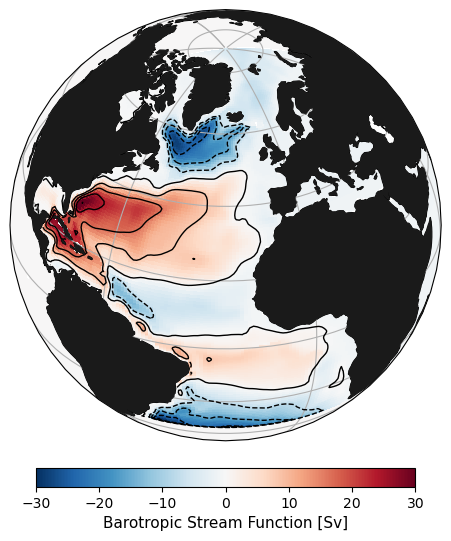

In [8]:
# -- Create a Figure with an orthographic (globe) projection -- #
fig = plt.figure(figsize=(7, 7))
proj = ccrs.Orthographic(central_longitude=-25, central_latitude=35)
ax = plt.axes(projection=proj)
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor='0.1', edgecolor='0.1', linewidth=0.2, zorder=4)
ax.gridlines(draw_labels=False, dms=True, x_inline=False, y_inline=False)

# Plot eORCA1 JRA55v1 time-mean barotropic stream function:
c_parent = ax.pcolormesh(bsf_atl['glamv'], bsf_atl['gphiv'], bsf_atl.mean(dim='time_counter'),
                         transform=ccrs.PlateCarree(),
                         cmap="RdBu_r", shading="auto",
                         vmin=-30, vmax=30,
                         zorder=1)

# Plot eORCA1 JRA55v1 time-mean barotropic stream function contours:
plt.contour(bsf_atl['glamv'], bsf_atl['gphiv'], bsf_atl.mean(dim='time_counter'),
            levels=8, colors='k', linewidths=1,
            transform=ccrs.PlateCarree(),
            zorder=2)

# Add colorbar with label:
cb = plt.colorbar(c_parent, orientation="horizontal", pad=0.05, shrink=0.7)
cb.set_label("Barotropic Stream Function [Sv]", fontsize=11)
